# HYDRO30 Surface Water Extent Map from Sentinel-1 SAR

Create water masks from NRB data in an DEA's Open Data Cube (ODC), accessed via STAC. Using the ASF's HydroSAR algorithm

<img style= "padding: 7px" src="https://courses.edx.org/asset-v1:AlaskaX+SAR-401+3T2020+type@asset+block@Watermappingworkflow2.jpg" width="60%"/>


## Import libraries

Need to install the branch of HydroSAR that is set up for odc-stac

In [1]:
# !git clone --depth 1 --branch feature/odc_data_access https://github.com/HydroSAR/HydroSAR.git
# python -m pip install HydroSAR 

In [2]:
from odc.stac import load
from pystac_client import Client
from odc.stac import configure_s3_access
from odc.geo import BoundingBox

import rioxarray as rxr
import numpy as np
import xarray as xr

from tqdm.auto import tqdm
from pathlib import Path
from hydrosar.water_map import make_water_map

## Analysis Parameters

In [3]:
central_lat, central_lon = -35.1021, 149.4229
buffer = 0.12

aus_start_date = "2025-01-01"
aus_end_date = "2025-09-30"



The example below accesses a small stack of NRB data from Digital Earth Australia's (DEA's) ODC

**Open a STAC client to the catalog and configure anonymous access to AWS S3**

In [4]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"

stac_client = Client.open(catalog)

configure_s3_access(
    cloud_defaults=True, 
    aws_unsigned=True,
)

View the region we're loading

In [5]:
aus_bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

aus_bbox.explore()

## Query the STAC catalog

In [6]:
collections_query = ["ga_s1_nrb_iw_vv_vh_0"]
aus_date_query = f"{aus_start_date}/{aus_end_date}"
aus_bbox_query = aus_bbox.bbox

aus_items = stac_client.search(
    collections=collections_query,
    datetime=aus_date_query,
    bbox=aus_bbox_query
).item_collection()

print(f"Found {len(aus_items)} items")

Found 202 items


## Load the data into an `xarray.Dataset`

In [7]:
# Lazy load our filtered data
ds = load(
    aus_items,
    crs="utm",
    resolution=20,
    intersects=aus_bbox.boundary(),
    bands=["VV_gamma0", "VH_gamma0", "mask"],
    groupby="solar_day",
    chunks={},
)

ds = ds.rename({'VV_gamma0': 'VV', 'VH_gamma0': 'VH'})

## Resample


In [8]:
ds = ds.resample(time='MS').mean().compute()
ds

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 110MB
Dimensions:      (time: 6, y: 1358, x: 1127)
Coordinates:
  * y            (y) float64 11kB 6.127e+06 6.126e+06 ... 6.099e+06 6.099e+06
  * x            (x) float64 9kB 7.096e+05 7.096e+05 ... 7.321e+05 7.321e+05
    spatial_ref  int32 4B 32755
  * time         (time) datetime64[ns] 48B 2025-01-01 2025-02-01 ... 2025-06-01
Data variables:
    VV           (time, y, x) float32 37MB 0.0685 0.05617 ... 0.1735 0.1273
    VH           (time, y, x) float32 37MB 0.02409 0.02118 ... 0.07323 0.02136
    mask         (time, y, x) float32 37MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Create water masks using HydroSAR

Results will be exported as COG's into the folder 'water_masks'

In [31]:
water_mask_dir = Path.cwd() / "water_masks"
water_mask_dir.mkdir(exist_ok=True)

for dt in tqdm(ds.time):
    vv = ds["VV"].sel(time=dt)
    vh = ds["VH"].sel(time=dt)

    date = "".join(str(dt.values.astype("datetime64[D]")).split("-"))
    water_extent_output = water_mask_dir / f'water_extent_{date}.tif'

    make_water_map(
        water_extent_output, 
        vv, 
        vh, 
        tile_shape=(500, 500),
        # max_vv_threshold=-30, 
        # max_vh_threshold=-24., 
        # hand_threshold=15., 
        # hand_fraction=0.8
    )

  0%|          | 0/6 [00:00<?, ?it/s]

Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db
Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db
Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db
Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db
Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db
Tile selection did not converge! using default threshold -23.0 db
Tile selection did not converge! using default threshold -15.5 db


*HYDRO30_STAC_Processing.ipynb - Version 1.1.0 - Sept 2025*

## Open and plot the results

In [32]:
#recreate the time series
arrs=[]
for dt in ds.time:

    date = "".join(str(dt.values.astype("datetime64[D]")).split("-"))
    wm = rxr.open_rasterio(f'water_masks/water_extent_{date}.tif').squeeze().drop_vars('band')
    wm = wm.expand_dims(time=[dt.values])
    arrs.append(wm)

water_extent = xr.concat(arrs, dim='time')

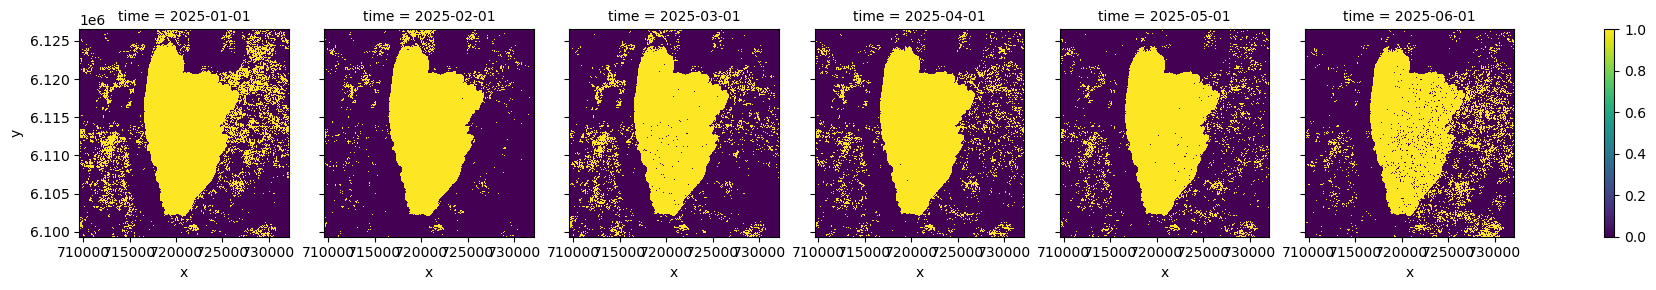

In [33]:
water_extent.plot.imshow(col='time');